## Proses Import Library

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

## Proses Load Dataset Hasil Feature Engineering

In [23]:
data_model = pd.read_csv(
    r"D:\Dokumen Bootcamp Dibimbing 2025\[WAJIB] Final Take Home Test\Take Home Test_Raihan Azhar Rafi\Data\data_model_final.csv"
)

data_model.head()

,User_id,target_pembelian,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,51443820326,0,1,0,0,0,0
1,51448162784,1,2,1,2,2,2
2,51455512201,1,2,2,2,1,1
3,51462598385,1,4,4,1,2,2
4,51463622150,1,4,2,1,2,2


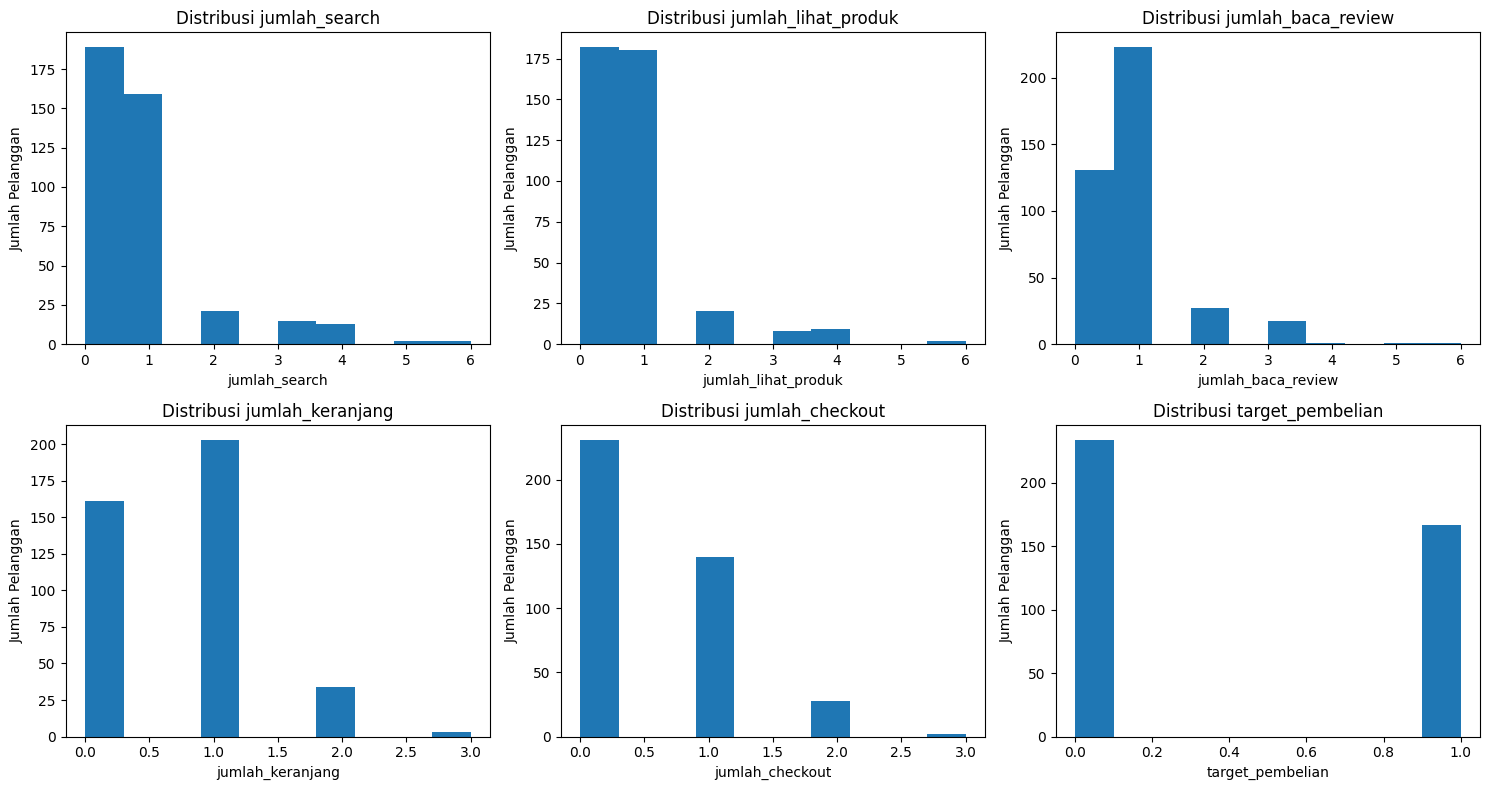

In [24]:
import matplotlib.pyplot as plt

fitur = [
    "jumlah_search",
    "jumlah_lihat_produk",
    "jumlah_baca_review",
    "jumlah_keranjang",
    "jumlah_checkout",
    "target_pembelian"
]

plt.figure(figsize=(15,8))

for i, kolom in enumerate(fitur, 1):

    plt.subplot(2,3,i)

    plt.hist(
        data_model[kolom],
        bins=10
    )

    plt.title(
        f"Distribusi {kolom}"
    )

    plt.xlabel(kolom)
    plt.ylabel("Jumlah Pelanggan")

plt.tight_layout()

plt.show()

## Insight Proses Load Dataset Hasil Feature Engineering

1. Dataset hasil feature engineering berhasil dimuat dan dijalankan untuk kebutuhan proses Machine Learning. Dataset tersebut berisi fitur perilaku pelanggan dan target pembelian yang akan diprediksi.

## Proses Ringkasan Dataset

In [26]:
ringkasan_dataset = pd.DataFrame({
    "Informasi": [
        "Jumlah Pelanggan",
        "Jumlah Fitur",
        "Target"
    ],
    "Nilai": [
        data_model.shape[0],
        data_model.shape[1]-1,
        "target_pembelian"
    ]
})

ringkasan_dataset

,Informasi,Nilai
0,Jumlah Pelanggan,401
1,Jumlah Fitur,6
2,Target,target_pembelian


## Proses Visualisasi Distribusi Target Pembelian

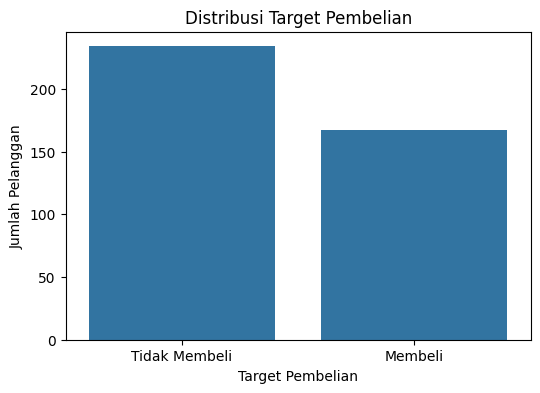

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=data_model,
    x="target_pembelian"
)

plt.title(
    "Distribusi Target Pembelian"
)

plt.xlabel(
    "Target Pembelian"
)

plt.ylabel(
    "Jumlah Pelanggan"
)

plt.xticks(
    [0,1],
    ["Tidak Membeli","Membeli"]
)

plt.show()

## Proses Memisahkan Fitur dan Target

In [28]:
fitur = data_model[
    [
        "jumlah_search",
        "jumlah_lihat_produk",
        "jumlah_baca_review",
        "jumlah_keranjang",
        "jumlah_checkout"
    ]
]

target = data_model["target_pembelian"]
fitur.head()

,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,1,0,0,0,0
1,2,1,2,2,2
2,2,2,2,1,1
3,4,4,1,2,2
4,4,2,1,2,2


## Insight Proses Memisahkan Fitur dan Target

1. Di tahap ini dataset dipisah menjadi variabel fitur (X) dan variabel target (y) untuk keperluan pelatihan model Machine Learning.
2. Variable fitur berisi informasi perilaku pelanggan di platform e-commerce, terdiri dari:
- jumlah_search
- jumlah_lihat_produk
- jumlah_baca_review
- jumlah_keranjang
- jumlah_checkout
Variable target berisi informasi apakah pelanggan melakukan pembelian atau tidak, terdiri dari: 
- target_pembelian
3. Pemisahan fitur dan target ini dilakukan sebelum proses Train Test Split dan pelatihan model dilakukan.

## Proses Train Test Split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    fitur,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

## Insight Proses Train Test Split

1. Di tahap ini aku menggunakan 80% data untuk pelatihan model, sedangkan 20% data sisanya untuk evaluasi model. Di sini stratify digunakan agar proporsi target tetap seimbang.

## Proses Feature Scaling

In [30]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(
    x_train
)

x_test_scaled = scaler.transform(
    x_test
)

## Insight Proses Feature Scaling

1. Scaler itu digunakan untuk menyamakan rentang nilai antar fitur agar tidak ada fitur yang memiliki pengaruh terlalu besar hanya karena nilainya lebih besar. Makanya data training tersebut digunakan untuk membangun scaler guna menghindari data leakage (kondisi dimana informasi dari data testing tidak sengaja digunakan saat proses pelatihan model jadi hasil evaluasinya tidak realistis).

## Proses Pelatihan Model Random Forest

In [31]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(
    x_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

## Insight Proses Pelatihan Model Random Forest

1. Aku memilih menggunakan Random Forest untuk proses modelling karena bisa handling data non-linear dengan baik. Model yang dibangun memakai 100 decision tree.

## Proses Prediksi Data Testing

In [32]:
prediksi_rf = model_rf.predict(
    x_test_scaled
)

## Proses Evaluasi Model

In [33]:
akurasi_rf = accuracy_score(
    y_test,
    prediksi_rf
)

print(
    "Akurasi Random Forest:\n",
    akurasi_rf
)

print(
    classification_report(
        y_test,
        prediksi_rf
    )
)

Akurasi Random Forest:
 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        34

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



## Proses Visualisasi Confusion Matrix

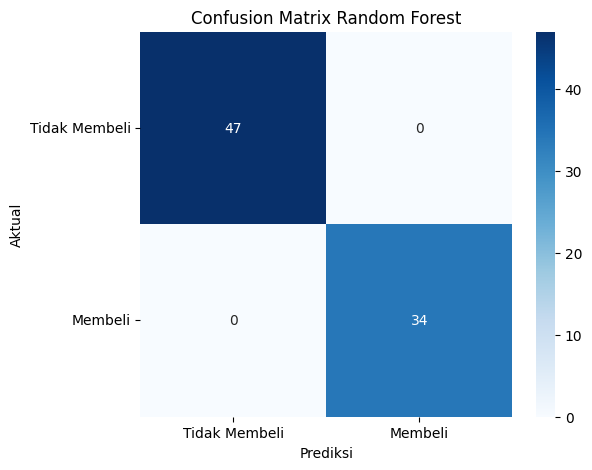

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    prediksi_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.xticks(
    [0.5,1.5],
    ["Tidak Membeli","Membeli"]
)

plt.yticks(
    [0.5,1.5],
    ["Tidak Membeli","Membeli"],
    rotation=0
)

plt.show()

## Insight Proses Visualisasi Confusion Matrix

1. Model Random Forest berhasil mengklasifikasikan pelanggan yang membeli dan tidak membeli berdasarkan fitur hasil Feature Engineering dengan sangat baik.
2. Hasil Confusion Matrix menunjukkan tidak terdapat kesalahan klasifikasi pada proses data testing, sehingga model menghasilkan akurasi sebesar 100%.
3. Meskipun akurasi yang diperoleh sangat tinggi, selanjutnya diperlukan proses Cross Validation untuk memastikan bahwa model tidak mengalami overfitting dan tetap memiliki kemampuan generalisasi yang baik terhadap data baru.

## Proses ROC Curve Random Forest

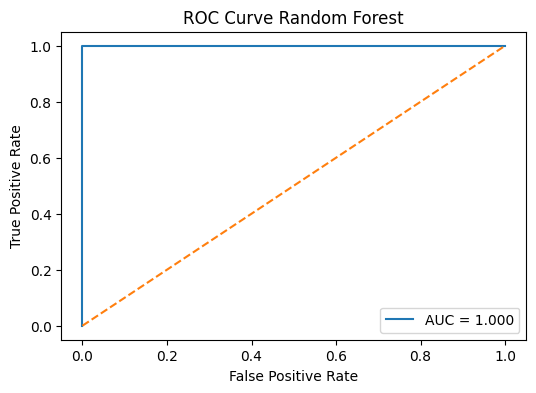

In [35]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

probabilitas_rf = model_rf.predict_proba(
    x_test_scaled
)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    probabilitas_rf
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Random Forest"
)

plt.legend()

plt.show()

## Insight Proses ROC Curve Random Forest

1. Model Random Forest menghasilkan nilai AUC sebesar 1.000 yang menunjukkan kemampuan klasifikasi yang sangat tinggi dan baik.
2. Model mampu membedakan pelanggan membeli dan tidak membeli dengan tingkat kesalahan yang sangat rendah.
3. Hasil ROC Curve konsisten dengan Confusion Matrix dan Classification Report yang menunjukkan performa model sangat baik.

## Proses Cross Validation

In [36]:
cv_score = cross_val_score(
    model_rf,
    x_train_scaled,
    y_train,
    cv=5
)

print(
    "Rata-rata CV:",
    cv_score.mean()
)

Rata-rata CV: 0.984375


## Insight Proses Cross Validation

1. Cross Validation dilakukan menggunakan metode 5-Fold Cross Validation, teknik tersebut melakukan evaluasi model yang membagi data training menjadi lima bagian untuk mengukur kestabilan performa model pada beberapa kombinasi data yang berbeda. Tujuannya untuk memastikan bahwa performa model tetap konsisten dan tidak hanya bagus pada satu pembagian data saja.
2. Model Random Forest menghasilkan rata-rata akurasi Cross Validation sebesar 98,44%. Hal tersebut menunjukkan  bahwa model memiliki performa prediksi yang sangat baik.
3. Selisih antara akurasi testing sebesar 100% dan rata-rata Cross Validation sebesar 98,44% terbilang relatif kecil, sehingga tidak menunjukkan indikasi overfitting yang signifikan. Hasil tersebut dinilai stabil dan siap digunakan untuk memprediksi potensi pembelian pelanggan.

## Proses Melihat Feature Importance

In [37]:
importance = pd.DataFrame({
    "fitur": fitur.columns,
    "importance": model_rf.feature_importances_
})

importance.sort_values(
    by="importance",
    ascending=False
)

,fitur,importance
4,jumlah_checkout,0.811146
3,jumlah_keranjang,0.096018
0,jumlah_search,0.058005
1,jumlah_lihat_produk,0.018963
2,jumlah_baca_review,0.015869


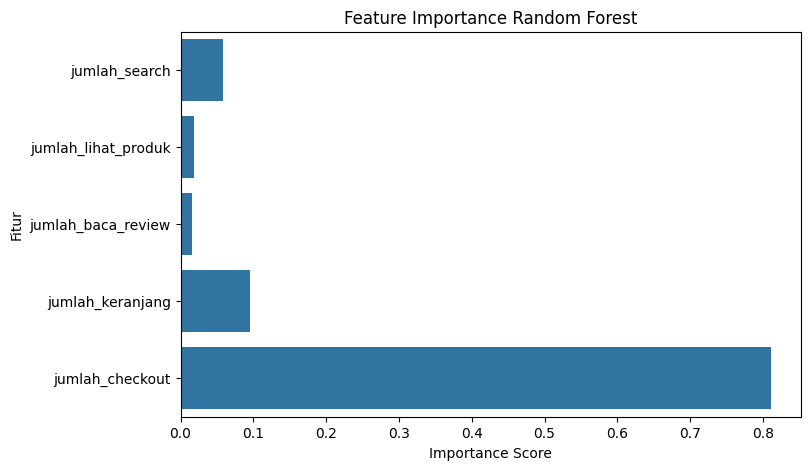

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="importance",
    y="fitur"
)

plt.title(
    "Feature Importance Random Forest"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Fitur"
)

plt.show()

## Insight Proses Melihat Feature Importance

1. Fitur jumlah_checkout memiliki nilai importance sebesar 0,811 (81,1%) sehingga menjadi faktor paling dominan dalam model. Hal tersebut menunjukkan bahwa aktivitas checkout merupakan indikator utama yang membedakan pelanggan yang membeli dan tidak membeli.
2. Terdapat perbedaan yang cukup signifikan antara jumlah_checkout 0,811 (81,1%) dan jumlah_keranjang 0,096 (9,6%). Temuan tersebut menunjukkan bahwa pelanggan yang mencapai tahap checkout memiliki kemungkinan pembelian yang jauh lebih tinggi dibandingkan pelanggan yang hanya menambahkan produk ke keranjang.
3. Aktivitas eksplorasi seperti pencarian produk, melihat produk, dan membaca review hanya memberikan kontribusi sekitar 9,3% terhadap keputusan model. Hal tersebut menunjukkan bahwa 3 aktivitas tersebut belum cukup kuat untuk memprediksi pembelian pelanggan secara akurat.
4. Berdasarkan hasil analisis tersebut menunjukkan bahwa strategi bisnisnya harus berfokus pada peningkatan jumlah pelanggan yang mencapai tahap checkout, karena berpotensi memberikan dampak terbesar terhadap peningkatan tingkat pembelian pelanggan.

## Simulasi Prediksi Pelanggan Baru

In [39]:
pelanggan_baru = pd.DataFrame({
    "jumlah_search":[4],
    "jumlah_lihat_produk":[3],
    "jumlah_baca_review":[2],
    "jumlah_keranjang":[2],
    "jumlah_checkout":[1]
})

pelanggan_baru_scaled = scaler.transform(
    pelanggan_baru
)

prediksi = model_rf.predict(
    pelanggan_baru_scaled
)

probabilitas = model_rf.predict_proba(
    pelanggan_baru_scaled
)

print(
    "Prediksi:",
    prediksi[0]
)

print(
    "Probabilitas Membeli:",
    probabilitas[0][1]
)

Prediksi: 1
Probabilitas Membeli: 1.0


## Proses Menyimpan Model Prediksi Pembelian Pelanggan

In [40]:
import joblib

joblib.dump(
    model_rf,
    "../Model/random_forest.pkl"
)

['../Model/random_forest.pkl']

In [41]:
joblib.dump(
    scaler,
    "../Model/scaler.pkl"
)

['../Model/scaler.pkl']